# 한찢마

In [233]:
import pandas as pd

In [234]:
han = pd.read_excel('data/한계찢는천재마법사_댓글_유료결제구분_추가.xlsx')

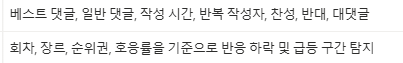

참여도 = 댓글 수 / 별점 참여 수

결제언급률 = *결제 키워드* 포함 댓글 수 / 전체 댓글 수

In [235]:
han.columns

Index(['title_id', 'episode_no', 'comment_no', 'author', 'content',
       'written_at', 'actual_written_at', 'like_count', 'dislike_count',
       'is_best', 'collected_at', 'episode_title', 'uploaded_at',
       'uploaded_at_dt', 'preview_comment_type', 'is_preview_paid_comment',
       'hours_before_upload'],
      dtype='object')

In [236]:
pd.crosstab(han['episode_no'],han['preview_comment_type'])

preview_comment_type,무료공개 이후 댓글,유료결제 댓글
episode_no,,
1,256,0
2,114,0
3,150,23
4,107,12
5,63,12
6,53,11
7,31,14
8,50,12
9,40,8


In [237]:
# 업로드 날짜가 00시로 되어있어서, 23시로 변경

han['uploaded_at_dt'] = han['uploaded_at_dt'] + pd.Timedelta(hours=23)
han['uploaded_at_dt'].dt.strftime('%Y-%m-%d %H:%M:%S')

0       2025-05-26 23:00:00
1       2025-05-26 23:00:00
2       2025-05-26 23:00:00
3       2025-05-26 23:00:00
4       2025-05-26 23:00:00
               ...         
2381    2026-05-25 23:00:00
2382    2026-05-25 23:00:00
2383    2026-05-25 23:00:00
2384    2026-05-25 23:00:00
2385    2026-05-25 23:00:00
Name: uploaded_at_dt, Length: 2386, dtype: object

In [238]:
han['after_3'] = han['uploaded_at_dt'] + pd.Timedelta(hours=3)
han['after_72'] = han['uploaded_at_dt'] + pd.Timedelta(hours=72)

In [239]:
han[['uploaded_at_dt','after_3','after_72']]

,uploaded_at_dt,after_3,after_72
0,2025-05-26 23:00:00,2025-05-27 02:00:00,2025-05-29 23:00:00
1,2025-05-26 23:00:00,2025-05-27 02:00:00,2025-05-29 23:00:00
2,2025-05-26 23:00:00,2025-05-27 02:00:00,2025-05-29 23:00:00
3,2025-05-26 23:00:00,2025-05-27 02:00:00,2025-05-29 23:00:00
4,2025-05-26 23:00:00,2025-05-27 02:00:00,2025-05-29 23:00:00
...,...,...,...
2381,2026-05-25 23:00:00,2026-05-26 02:00:00,2026-05-28 23:00:00
2382,2026-05-25 23:00:00,2026-05-26 02:00:00,2026-05-28 23:00:00
2383,2026-05-25 23:00:00,2026-05-26 02:00:00,2026-05-28 23:00:00
2384,2026-05-25 23:00:00,2026-05-26 02:00:00,2026-05-28 23:00:00


In [240]:
df = han[['episode_no','content','actual_written_at', 'like_count', 'dislike_count',
       'is_best','episode_title','uploaded_at_dt', 'preview_comment_type','after_3', 'after_72']]
df

,episode_no,content,actual_written_at,like_count,dislike_count,is_best,episode_title,uploaded_at_dt,preview_comment_type,after_3,after_72
0,1,웟지 찢는 천재(天災) 대통령 ㅋㅋ,2026-05-26 16:04:00,0,0,False,1화,2025-05-26 23:00:00,무료공개 이후 댓글,2025-05-27 02:00:00,2025-05-29 23:00:00
1,1,찢어? 어디를 찢어? 헉헉헉헉💀,2026-05-20 16:09:00,0,0,False,1화,2025-05-26 23:00:00,무료공개 이후 댓글,2025-05-27 02:00:00,2025-05-29 23:00:00
2,1,근데 똑똑하면 그냥 몸 건강히 연구만 시키면 되지 굳이 수명 단축 시켜가면서 실험체...,2026-05-19 16:09:00,0,0,False,1화,2025-05-26 23:00:00,무료공개 이후 댓글,2025-05-27 02:00:00,2025-05-29 23:00:00
3,1,한계 재매이 마법사 ㄷㄷ,2026-05-18 13:55:00,1,0,False,1화,2025-05-26 23:00:00,무료공개 이후 댓글,2025-05-27 02:00:00,2025-05-29 23:00:00
4,1,신에게 곧 갈거라고......To Be Continued.......,2026-05-05 10:46:00,0,0,False,1화,2025-05-26 23:00:00,무료공개 이후 댓글,2025-05-27 02:00:00,2025-05-29 23:00:00
...,...,...,...,...,...,...,...,...,...,...,...
2381,54,재밌다 헤헤,2026-03-24 02:02:00,4,0,False,54화,2026-05-25 23:00:00,유료결제 댓글,2026-05-26 02:00:00,2026-05-28 23:00:00
2382,54,섬멸대 내부에 글러트니가?,2026-03-24 01:30:00,8,3,False,54화,2026-05-25 23:00:00,유료결제 댓글,2026-05-26 02:00:00,2026-05-28 23:00:00
2383,54,숨바꼭질,2026-03-24 00:40:00,1,0,False,54화,2026-05-25 23:00:00,유료결제 댓글,2026-05-26 02:00:00,2026-05-28 23:00:00
2384,54,베댓 한번만요,2026-03-23 23:41:00,2,1,False,54화,2026-05-25 23:00:00,유료결제 댓글,2026-05-26 02:00:00,2026-05-28 23:00:00


1. 사전 호응률 = 업로드 이전 댓글 수(유료독자) / 업로드 72시간 후 댓글 수 
2. 초기 호응률 = 업로드 3시간 후 댓글 수 - 업로드 이전 댓글 수 / 업로드 72시간 후  댓글 수
3. 최종 호응률 = 업로드 72시간 후 댓글 수 / 전체 댓글 수

In [241]:
cond1 = df['preview_comment_type'] == '무료공개 이후 댓글'
cond2 = df['actual_written_at'] <= df['after_3']
cond3 = df['actual_written_at'] <= df['after_72']

In [242]:
# 회차별 전체 댓글 수
t0 = df['episode_no'].value_counts().reset_index().sort_values(by= 'episode_no')
t0

,episode_no,count
0,1,256
3,2,114
1,3,173
2,4,119
4,5,75
5,6,64
12,7,45
6,8,62
11,9,48
46,10,23


In [243]:
# 회차별 유료 결제 댓글 수 (유료만)
t1 = pd.crosstab(df['episode_no'],df['preview_comment_type'])['유료결제 댓글'].reset_index()
t1

,episode_no,유료결제 댓글
0,1,0
1,2,0
2,3,23
3,4,12
4,5,12
5,6,11
6,7,14
7,8,12
8,9,8
9,10,5


In [244]:
# 회차별 업로드 72시간까지의 댓글 수 (유료, 무료 모두 포함)
t2 = df.loc[cond3,'episode_no'].value_counts().reset_index().sort_values(by= 'episode_no').reset_index(drop=True)
t2

,episode_no,count
0,1,78
1,2,37
2,3,61
3,4,35
4,5,31
5,6,26
6,7,26
7,8,27
8,9,22
9,10,14


In [245]:
# 회차별 업로드 3시간까지의 댓글 수 (무료만)
t3 = df.loc[cond1&cond2, 'episode_no'].value_counts().reset_index().sort_values(by = 'episode_no').reset_index(drop=True)
t3

,episode_no,count
0,1,40
1,2,16
2,3,11
3,4,5
4,5,7
5,6,4
6,7,6
7,8,3
8,9,3
9,10,2


In [246]:
# 사전호응률 : 초반 반응 중 얼마나 많은 부분이 유료 선독자에게서 나왔는가
z1 = t1['유료결제 댓글'] / t2['count']
z1

0     0.000000
1     0.000000
2     0.377049
3     0.342857
4     0.387097
5     0.423077
6     0.538462
7     0.444444
8     0.363636
9     0.357143
10    0.285714
11    0.125000
12    0.619048
13    0.315789
14    0.666667
15    0.333333
16    0.400000
17    0.590909
18    0.458333
19    0.500000
20    0.583333
21    0.333333
22    0.666667
23    0.214286
24    0.333333
25    0.434783
26    0.272727
27    0.500000
28    0.600000
29    0.500000
30    0.500000
31    0.466667
32    0.733333
33    0.521739
34    0.500000
35    0.653846
36    0.680000
37    0.760000
38    0.548387
39    0.562500
40    0.521739
41    0.523810
42    0.500000
43    0.470588
44    0.476190
45    0.540541
46    0.500000
47    0.500000
48    0.425532
49    0.428571
50    0.500000
51    0.454545
52    0.631579
53    0.470588
dtype: float64

In [247]:
# 초기호응률 : 무료 공개 직후 얼마나 빠르게 반응이 발생했는가
z2 = t3['count'] / t2['count']
z2

0     0.512821
1     0.432432
2     0.180328
3     0.142857
4     0.225806
5     0.153846
6     0.230769
7     0.111111
8     0.136364
9     0.142857
10    0.250000
11    0.458333
12    0.142857
13    0.315789
14    0.041667
15    0.333333
16    0.150000
17    0.136364
18    0.166667
19    0.062500
20    0.250000
21    0.055556
22    0.133333
23    0.142857
24    0.111111
25    0.217391
26    0.272727
27    0.250000
28    0.100000
29    0.150000
30    0.357143
31    0.200000
32    0.133333
33    0.173913
34    0.230769
35    0.115385
36    0.080000
37    0.080000
38    0.096774
39    0.062500
40    0.130435
41    0.238095
42    0.125000
43    0.117647
44    0.142857
45    0.108108
46    0.125000
47    0.214286
48    0.234043
49    0.250000
50    0.166667
51    0.181818
52    0.157895
53         NaN
Name: count, dtype: float64

In [248]:
# 최종호응률 : 전체 반응 중 얼마나 많은 반응이 초반 3일에 집중됐는가
z3 = t3['count'] / t0['count']
z3

0     0.156250
1     0.092486
2     0.092437
3     0.043860
4     0.093333
5     0.062500
6     0.096774
7     0.058824
8     0.062500
9     0.041667
10    0.145833
11    0.229167
12    0.066667
13    0.139535
14    0.025000
15    0.125000
16    0.076923
17    0.078947
18    0.105263
19    0.027027
20    0.081081
21    0.027027
22    0.054054
23    0.055556
24    0.055556
25    0.142857
26    0.171429
27    0.176471
28    0.058824
29    0.090909
30    0.156250
31    0.093750
32    0.064516
33    0.129032
34    0.200000
35    0.103448
36    0.068966
37    0.071429
38    0.107143
39    0.037037
40    0.111111
41    0.185185
42    0.120000
43    0.083333
44    0.125000
45    0.166667
46    0.086957
47    0.272727
48    0.523810
49    0.350000
50    0.200000
51    0.210526
52    0.176471
53         NaN
Name: count, dtype: float64

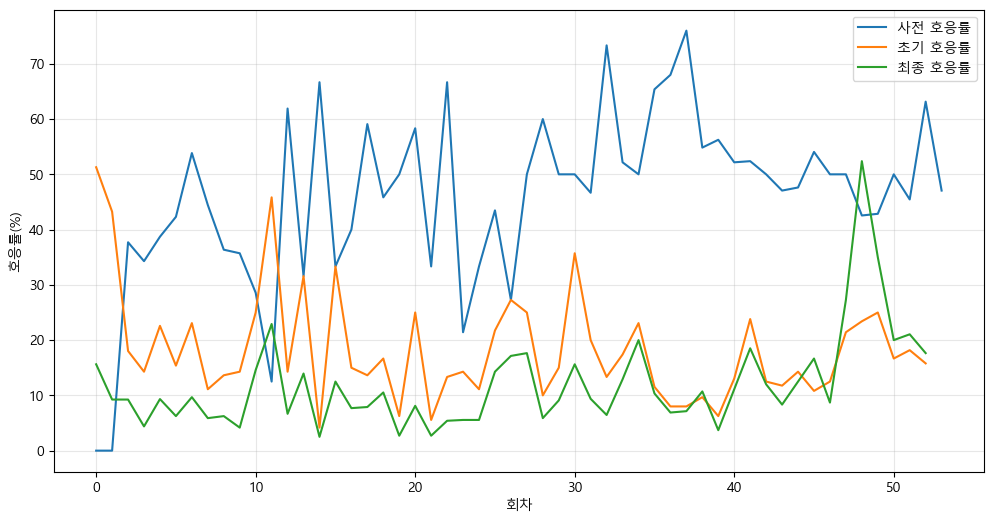

In [249]:
plt.figure(figsize=(12,6))

plt.plot(z1*100, label='사전 호응률')
plt.plot(z2*100, label='초기 호응률')
plt.plot(z3*100, label='최종 호응률')

plt.ylabel('호응률(%)')
plt.xlabel('회차')

plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [208]:
result = pd.DataFrame({
    '사전호응률': z1,
    '초기호응률': z2,
    '최종호응률': z3
})
result.index = range(1, len(result)+1)
result

,사전호응률,초기호응률,최종호응률
1,0.000000,0.512821,0.156250
2,0.000000,0.432432,0.092486
3,0.377049,0.180328,0.092437
4,0.342857,0.142857,0.043860
5,0.387097,0.225806,0.093333
6,0.423077,0.153846,0.062500
7,0.538462,0.230769,0.096774
8,0.444444,0.111111,0.058824
9,0.363636,0.136364,0.062500
10,0.357143,0.142857,0.041667


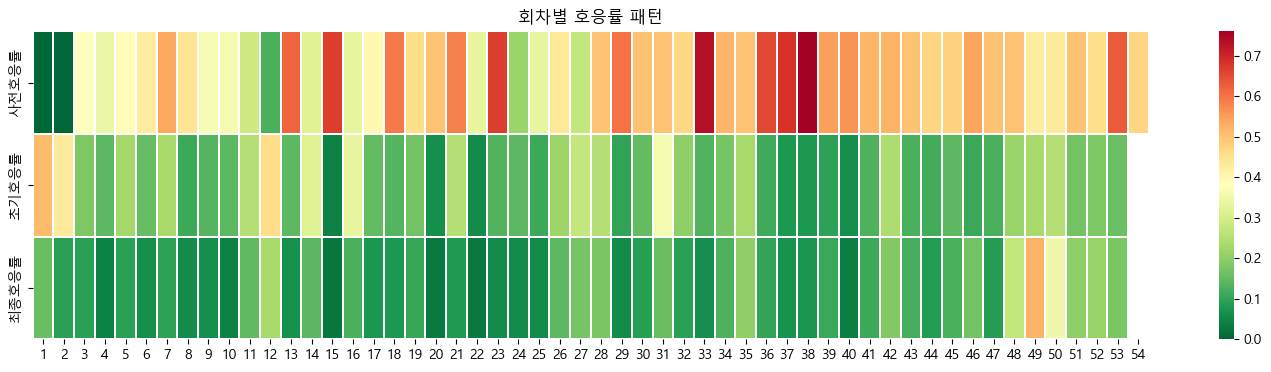

In [209]:
import seaborn as sns

plt.figure(figsize=(18,4))

sns.heatmap(
    result.T,
    cmap='RdYlGn_r',
    annot=False,      # 숫자 제거
    linewidths=0.3
)

plt.title('회차별 호응률 패턴')
plt.show()

In [210]:
result['팬덤의존도'] = result['사전호응률'] - result['초기호응률']

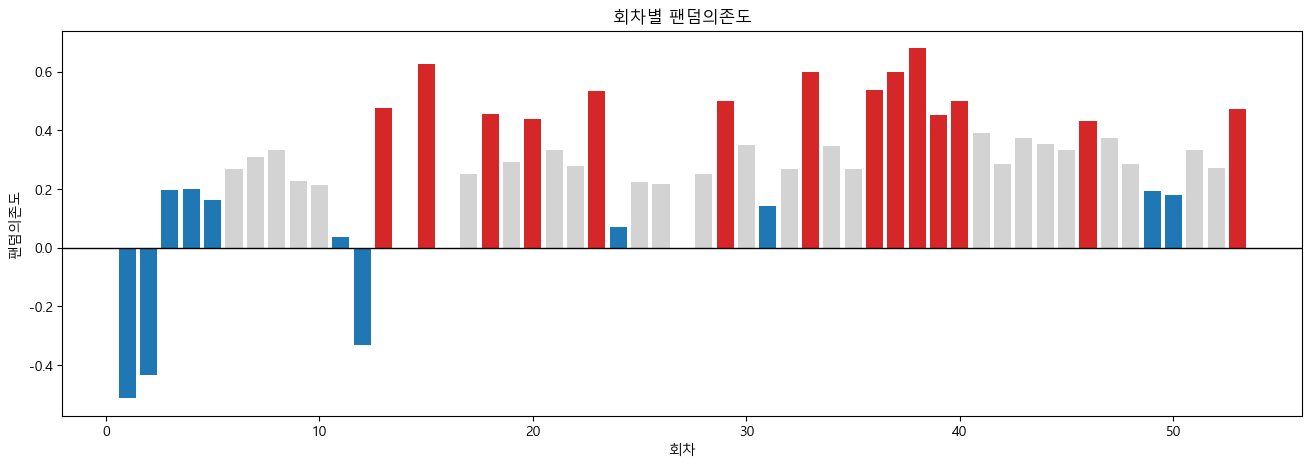

In [211]:
q75 = result['팬덤의존도'].quantile(0.75)
q25 = result['팬덤의존도'].quantile(0.25)

colors = []

for x in result['팬덤의존도']:
    if x >= q75:
        colors.append('#D62728')   # 상위 25%
    elif x <= q25:
        colors.append('#1F77B4')   # 하위 25%
    else:
        colors.append('#D3D3D3')   # 중간 50%

plt.figure(figsize=(16,5))

plt.bar(
    result.index,
    result['팬덤의존도'],
    color=colors
)

plt.axhline(0, color='black', linewidth=1)

plt.title('회차별 팬덤의존도')
plt.xlabel('회차')
plt.ylabel('팬덤의존도')

plt.show()

1. 작품이 진행될수록 신규나 무료 독자보다는 유료 독자 중심으로 소비되는 경향
2. 최근 화로 갈수록 독자층이 다시 균형을 찾아가고 있다 -> 유료 독자의 반응이 줄어들고 있다. or 무료 독자 반응이 늘어났다
3. 절대적 댓글 수 비교를 보면 무료 독자 반응이 늘어나고 있는 것으로 보임

🔴 빨강 = 팬덤 의존도가 특히 높은 회차

⚪ 회색 = 평범한 회차

🔵 파랑 = 무료 독자 반응이 특히 강한 회차

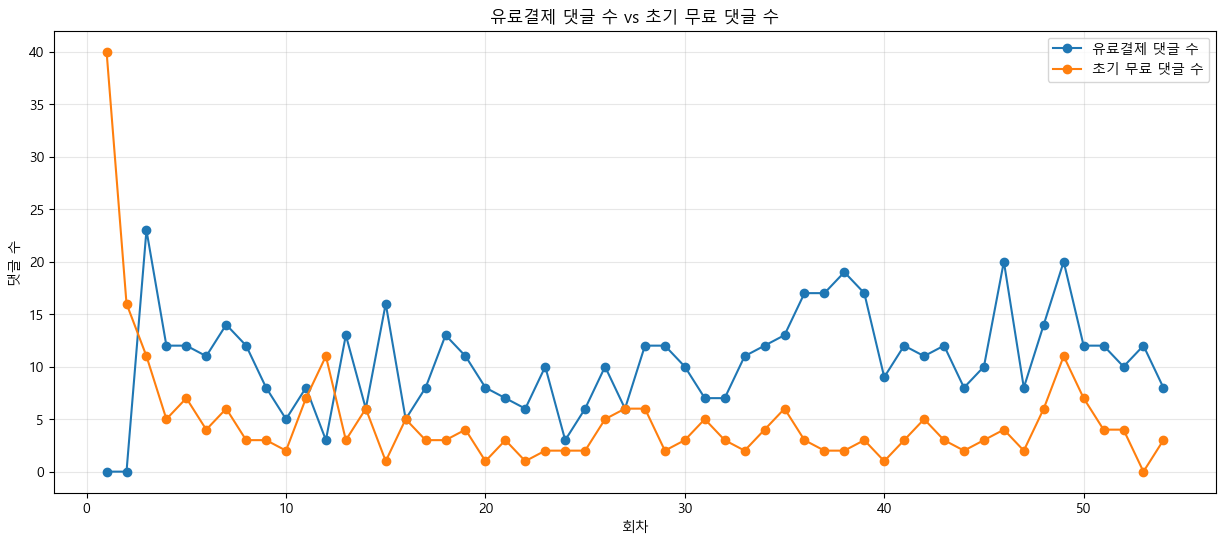

In [212]:
paid_cnt = t1.set_index('episode_no')['유료결제 댓글']
free_3h_cnt = t3.set_index('episode_no')['count']

paid_cnt = paid_cnt.reindex(result.index).fillna(0)
free_3h_cnt = free_3h_cnt.reindex(result.index).fillna(0)

plt.figure(figsize=(15,6))

plt.plot(
    result.index,
    paid_cnt,
    marker='o',
    label='유료결제 댓글 수'
)

plt.plot(
    result.index,
    free_3h_cnt,
    marker='o',
    label='초기 무료 댓글 수'
)

plt.legend()
plt.grid(alpha=0.3)

plt.xlabel('회차')
plt.ylabel('댓글 수')
plt.title('유료결제 댓글 수 vs 초기 무료 댓글 수')

plt.show()

In [213]:
keywords = r'쿠키|결제|구웠|굽는다|질렀|미리보기|다음화|유료'

cond4 = df['content'].str.contains(
    keywords,
    na=False
)

In [214]:
result

,사전호응률,초기호응률,최종호응률,팬덤의존도
1,0.000000,0.512821,0.156250,-0.512821
2,0.000000,0.432432,0.092486,-0.432432
3,0.377049,0.180328,0.092437,0.196721
4,0.342857,0.142857,0.043860,0.200000
5,0.387097,0.225806,0.093333,0.161290
6,0.423077,0.153846,0.062500,0.269231
7,0.538462,0.230769,0.096774,0.307692
8,0.444444,0.111111,0.058824,0.333333
9,0.363636,0.136364,0.062500,0.227273
10,0.357143,0.142857,0.041667,0.214286


In [215]:
# 회차별 결제언급률 : 72시간 댓글 
t4 = df[cond3&cond4]['episode_no'].value_counts().sort_index()
result['결제언급수'] = t4.reindex(result.index).fillna(0)

# 72시간 댓글 수 Series 만들기
comment_72 = t2.set_index('episode_no')['count']

result['결제언급률'] = (result['결제언급수']/ comment_72.reindex(result.index))

In [216]:
result

,사전호응률,초기호응률,최종호응률,팬덤의존도,결제언급수,결제언급률
1,0.000000,0.512821,0.156250,-0.512821,6.0,0.076923
2,0.000000,0.432432,0.092486,-0.432432,1.0,0.027027
3,0.377049,0.180328,0.092437,0.196721,3.0,0.049180
4,0.342857,0.142857,0.043860,0.200000,5.0,0.142857
5,0.387097,0.225806,0.093333,0.161290,1.0,0.032258
6,0.423077,0.153846,0.062500,0.269231,0.0,0.000000
7,0.538462,0.230769,0.096774,0.307692,3.0,0.115385
8,0.444444,0.111111,0.058824,0.333333,0.0,0.000000
9,0.363636,0.136364,0.062500,0.227273,1.0,0.045455
10,0.357143,0.142857,0.041667,0.214286,0.0,0.000000


In [217]:
# 생각보다 결제 언급률 자체는 부정적 의견도 많아서, 감성분석으로 접근하는게 훨신 나을듯

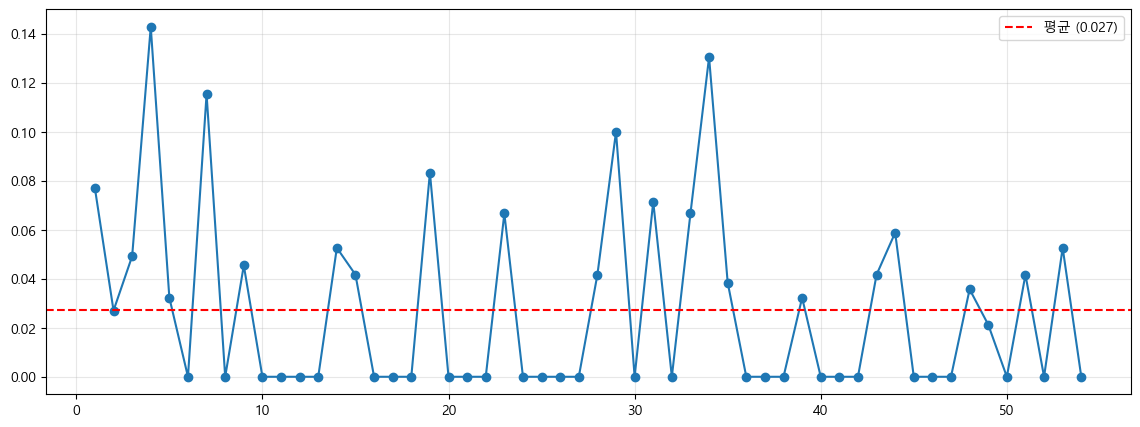

In [219]:
mean_val = result['결제언급률'].mean()

plt.figure(figsize=(14,5))

plt.plot(
    result.index,
    result['결제언급률'],
    marker='o'
)

plt.axhline(
    mean_val,
    color='red',
    linestyle='--',
    label=f'평균 ({mean_val:.3f})'
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

# 해피페이스

In [220]:
happy = pd.read_excel('data/해피페이스_댓글_유료결제구분_추가.xlsx')

In [221]:
# 업로드 날짜가 00시로 되어있어서, 23시로 변경

happy['uploaded_at_dt'] = happy['uploaded_at_dt'] + pd.Timedelta(hours=23)
happy['uploaded_at_dt'].dt.strftime('%Y-%m-%d %H:%M:%S')

happy['after_3'] = happy['uploaded_at_dt'] + pd.Timedelta(hours=3)
happy['after_72'] = happy['uploaded_at_dt'] + pd.Timedelta(hours=72)

In [222]:
df2 = happy[['episode_no','content','actual_written_at', 'like_count', 'dislike_count',
       'is_best','episode_title','uploaded_at_dt', 'preview_comment_type','after_3', 'after_72']]
df2

,episode_no,content,actual_written_at,like_count,dislike_count,is_best,episode_title,uploaded_at_dt,preview_comment_type,after_3,after_72
0,1,오.. 새 연재시작했구나.. 이제서야 알았네,2026-05-11 00:34:00,0,0,False,1화 - 투기장,2025-04-27 23:00:00,무료공개 이후 댓글,2025-04-28 02:00:00,2025-04-30 23:00:00
1,1,까망이작가님~~~~,2026-05-10 22:24:00,0,0,False,1화 - 투기장,2025-04-27 23:00:00,무료공개 이후 댓글,2025-04-28 02:00:00,2025-04-30 23:00:00
2,1,오 ㅅㅅ,2026-04-28 11:49:00,0,0,False,1화 - 투기장,2025-04-27 23:00:00,무료공개 이후 댓글,2025-04-28 02:00:00,2025-04-30 23:00:00
3,1,까망이 사람됐네,2026-04-20 20:51:00,0,0,False,1화 - 투기장,2025-04-27 23:00:00,무료공개 이후 댓글,2025-04-28 02:00:00,2025-04-30 23:00:00
4,1,이야..... 오늘부터 정주행이닷!!!!,2026-04-17 01:12:00,0,0,False,1화 - 투기장,2025-04-27 23:00:00,무료공개 이후 댓글,2025-04-28 02:00:00,2025-04-30 23:00:00
...,...,...,...,...,...,...,...,...,...,...,...
6576,56,딸은 아빠 닮는다더니..,2026-04-19 22:58:00,0,0,False,56화 - 피의 유산,2026-05-24 23:00:00,유료결제 댓글,2026-05-25 02:00:00,2026-05-27 23:00:00
6577,56,뭔가 해피 투기장 시절 아는 사람일듯 추격대 대장이란 사람,2026-04-19 22:57:00,99,2,True,56화 - 피의 유산,2026-05-24 23:00:00,유료결제 댓글,2026-05-25 02:00:00,2026-05-27 23:00:00
6578,56,해피 투기장 아버지는 진짜 멋쟁이시네,2026-04-19 22:57:00,341,3,True,56화 - 피의 유산,2026-05-24 23:00:00,유료결제 댓글,2026-05-25 02:00:00,2026-05-27 23:00:00
6579,56,2,2026-04-19 22:55:00,0,1,False,56화 - 피의 유산,2026-05-24 23:00:00,유료결제 댓글,2026-05-25 02:00:00,2026-05-27 23:00:00


In [223]:
cond1 = df2['preview_comment_type'] == '무료공개 이후 댓글'
cond2 = df2['actual_written_at'] <= df2['after_3']
cond3 = df2['actual_written_at'] <= df2['after_72']

In [224]:
# 회차별 전체 댓글 수
t0 = df2['episode_no'].value_counts().reset_index().sort_values(by= 'episode_no')

# 회차별 유료 결제 댓글 수 (유료만)
t1 = pd.crosstab(df2['episode_no'],df2['preview_comment_type'])['유료결제 댓글'].reset_index()

# 회차별 업로드 72시간까지의 댓글 수 (유료, 무료 모두 포함)
t2 = df2.loc[cond3,'episode_no'].value_counts().reset_index().sort_values(by= 'episode_no').reset_index(drop=True)

# 회차별 업로드 3시간까지의 댓글 수 (무료만)
t3 = df2.loc[cond1&cond2, 'episode_no'].value_counts().reset_index().sort_values(by = 'episode_no').reset_index(drop=True)

In [225]:
# 사전호응률 : 초반 반응 중 얼마나 많은 부분이 유료 선독자에게서 나왔는가
z1 = t1['유료결제 댓글'] / t2['count']

# 초기호응률 : 무료 공개 직후 얼마나 빠르게 반응이 발생했는가
z2 = t3['count'] / t2['count']

# 최종호응률 : 전체 반응 중 얼마나 많은 반응이 초반 3일에 집중됐는가
z3 = t3['count'] / t0['count']

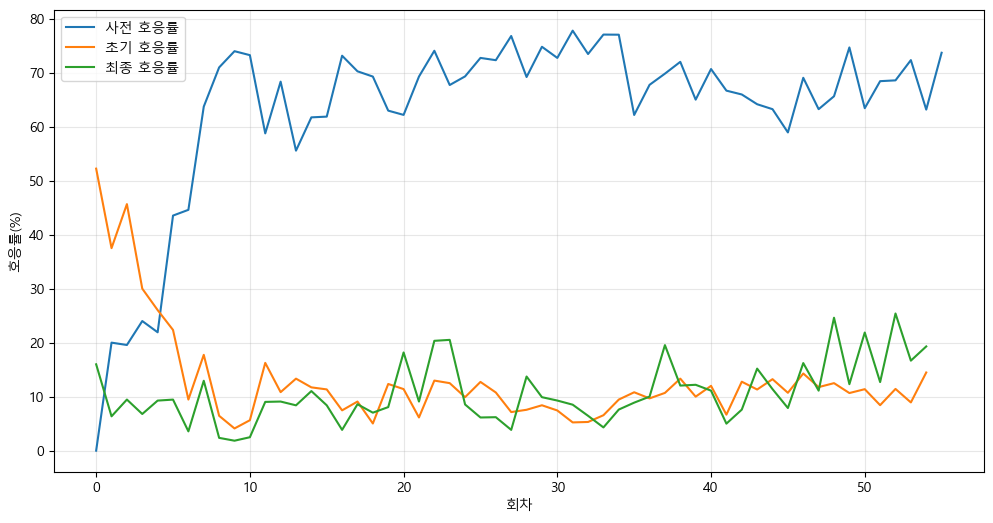

In [226]:
plt.figure(figsize=(12,6))

plt.plot(z1*100, label='사전 호응률')
plt.plot(z2*100, label='초기 호응률')
plt.plot(z3*100, label='최종 호응률')

plt.ylabel('호응률(%)')
plt.xlabel('회차')

plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [227]:
result = pd.DataFrame({
    '사전호응률': z1,
    '초기호응률': z2,
    '최종호응률': z3
})
result.index = range(1, len(result)+1)
result

,사전호응률,초기호응률,최종호응률
1,0.000000,0.522222,0.159864
2,0.200000,0.375000,0.063559
3,0.195652,0.456522,0.094595
4,0.240000,0.300000,0.067873
5,0.219178,0.260274,0.092683
6,0.435294,0.223529,0.094527
7,0.445946,0.094595,0.035714
8,0.637097,0.177419,0.129412
9,0.709677,0.064516,0.023669
10,0.739726,0.041096,0.018405


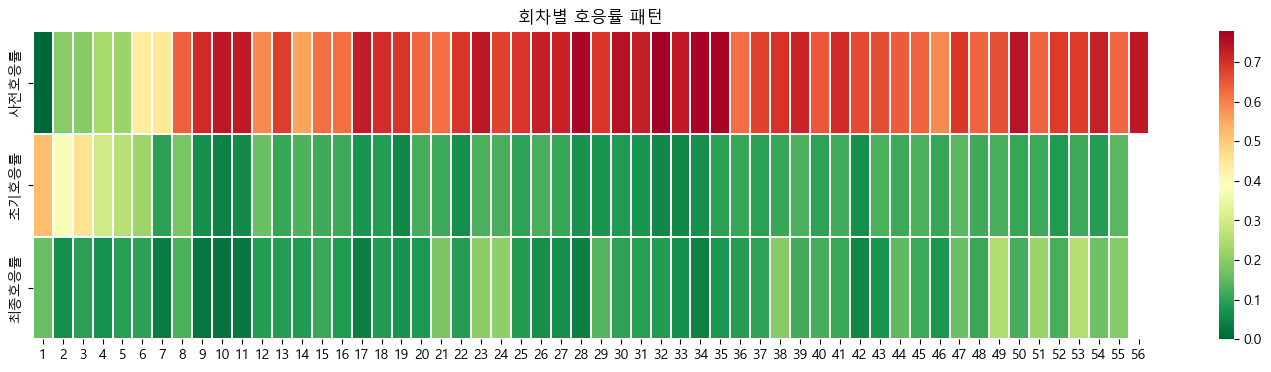

In [228]:
import seaborn as sns

plt.figure(figsize=(18,4))

sns.heatmap(
    result.T,
    cmap='RdYlGn_r',
    annot=False,      # 숫자 제거
    linewidths=0.3
)

plt.title('회차별 호응률 패턴')
plt.show()

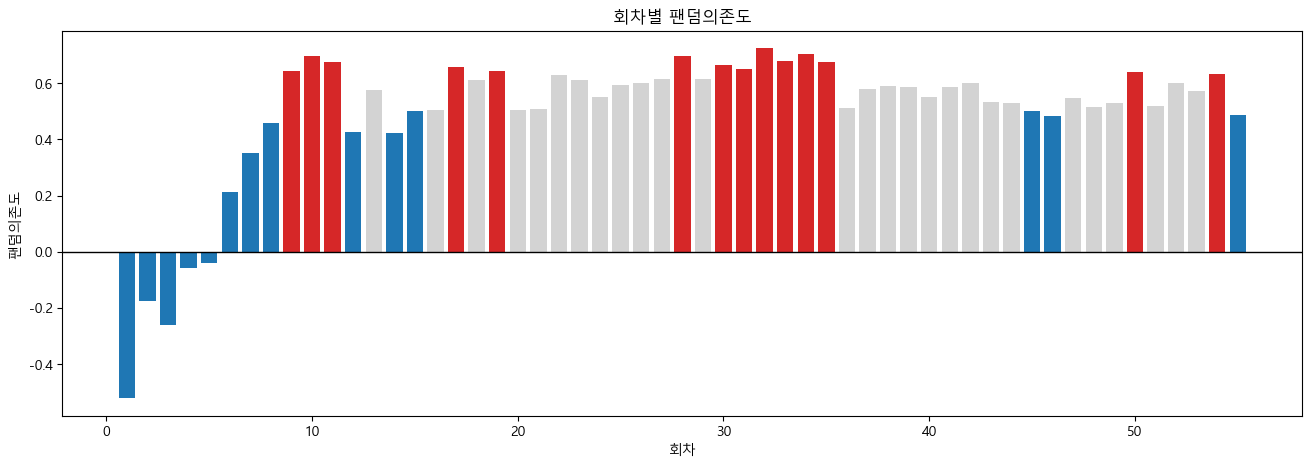

In [229]:
result['팬덤의존도'] = result['사전호응률'] - result['초기호응률']


q75 = result['팬덤의존도'].quantile(0.75)
q25 = result['팬덤의존도'].quantile(0.25)

colors = []

for x in result['팬덤의존도']:
    if x >= q75:
        colors.append('#D62728')   # 상위 25%
    elif x <= q25:
        colors.append('#1F77B4')   # 하위 25%
    else:
        colors.append('#D3D3D3')   # 중간 50%

plt.figure(figsize=(16,5))

plt.bar(
    result.index,
    result['팬덤의존도'],
    color=colors
)

plt.axhline(0, color='black', linewidth=1)

plt.title('회차별 팬덤의존도')
plt.xlabel('회차')
plt.ylabel('팬덤의존도')

plt.show()

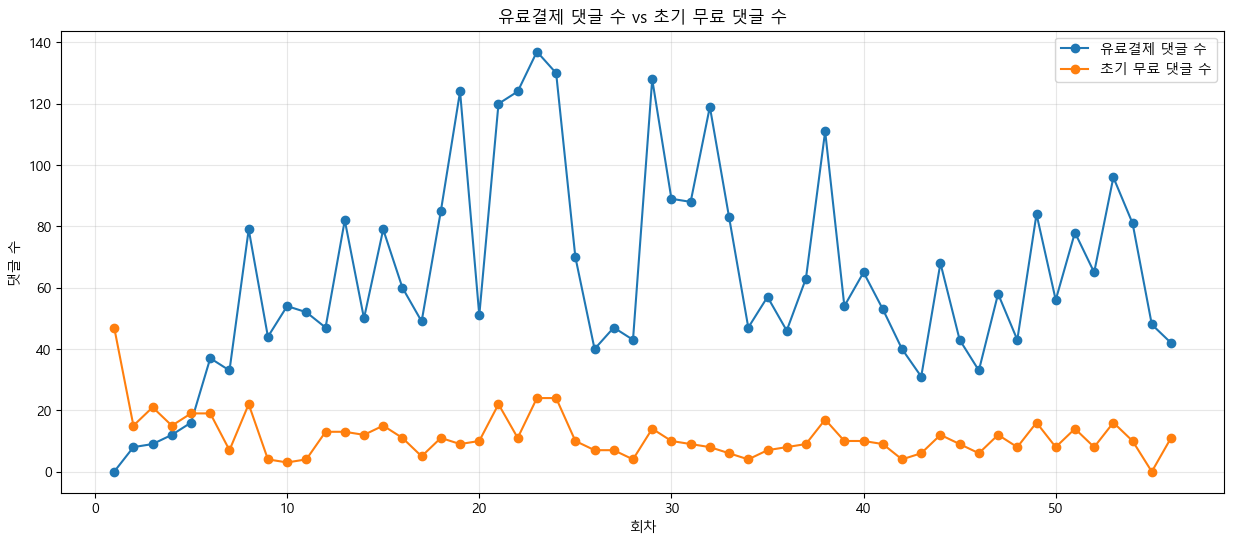

In [230]:
paid_cnt = t1.set_index('episode_no')['유료결제 댓글']
free_3h_cnt = t3.set_index('episode_no')['count']

paid_cnt = paid_cnt.reindex(result.index).fillna(0)
free_3h_cnt = free_3h_cnt.reindex(result.index).fillna(0)

plt.figure(figsize=(15,6))

plt.plot(
    result.index,
    paid_cnt,
    marker='o',
    label='유료결제 댓글 수'
)

plt.plot(
    result.index,
    free_3h_cnt,
    marker='o',
    label='초기 무료 댓글 수'
)

plt.legend()
plt.grid(alpha=0.3)

plt.xlabel('회차')
plt.ylabel('댓글 수')
plt.title('유료결제 댓글 수 vs 초기 무료 댓글 수')

plt.show()

In [231]:
keywords = r'쿠키|결제|구웠|굽는다|질렀|미리보기|다음화|유료'

cond4 = df2['content'].str.contains(
    keywords,
    na=False
)

# 회차별 결제언급률 : 72시간 댓글 
t4 = df2[cond3&cond4]['episode_no'].value_counts().sort_index()
result['결제언급수'] = t4.reindex(result.index).fillna(0)

# 72시간 댓글 수 Series 만들기
comment_72 = t2.set_index('episode_no')['count']

result['결제언급률'] = (result['결제언급수']/ comment_72.reindex(result.index))

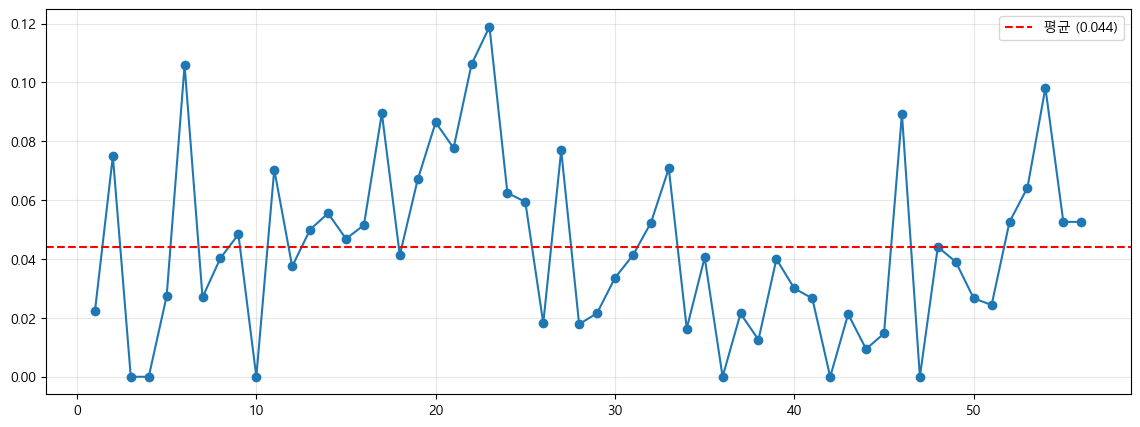

In [232]:
mean_val = result['결제언급률'].mean()

plt.figure(figsize=(14,5))

plt.plot(
    result.index,
    result['결제언급률'],
    marker='o'
)

plt.axhline(
    mean_val,
    color='red',
    linestyle='--',
    label=f'평균 ({mean_val:.3f})'
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()